In [1]:
import gym
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.kernel_approximation import Nystroem,RBFSampler

In [2]:
GAMMA=0.9
ALPHA=.1

In [17]:
def epsilon_greedy(model,s,eps=.1):
    p=np.random.random()
    if p<(1-eps):
        values=model.predict_all_actions(s)
        return np.argmax(values)
    else:
        return model.env.action_space.sample()

In [4]:
def gather_samples(env,n_episodes=10000):
    samples=[]
    for _ in range(n_episodes):
        s=env.reset()[0]
        done=False
        while not done:
            a=env.action_space.sample()
            sa=s.tolist()+[a]
            samples.append(sa)
            
            s,r,done,info,i=env.step(a)
    return samples
            
    

In [15]:
class Model:
    def __init__ (self,env):
        self.env=env
        samples=gather_samples(env)
        self.featurizer=RBFSampler()
        self.featurizer.fit(samples)
        dims = self.featurizer.n_components
        
        self.w=np.zeros(dims)
        
    def predict(self,s,a):
        sa= s.tolist()+[a]
        x= self.featurizer.transform([sa])[0]
        return x@self.w 
    
    def predict_all_actions(self,s):
        return [self.predict(s,a) for a in range(self.env.action_space.n)]
    
    def grad(self,s,a):
        sa= s.tolist()+[a]
        x=self.featurizer.transform([sa])[0]
        return x

In [21]:
def test_agent(model,env,n_episod=20):
    reward_per_episode=np.zeros(n_episod)
    for it in range(n_episod):
        done=False
        episode_reward=0
        s=env.reset()[0]
        while not done:
            a=epsilon_greedy(model,s,eps=0)
            s,r,done,info,i=env.step(a)
            episode_reward +=r
            
        reward_per_episode[it]=episode_reward
        
    return np.mean(reward_per_episode)

In [7]:
def watch_agent(model,env,eps):
    done=False
    episode_reward=0
    s=env.reset()[0]
    while not done:
        a=epsilon_greedy(model,s,eps=eps)
        s,r,done,info,i=env.step(a)
        env.render()
        episode_reward +=r
    print("Episod reward:",episode_reward)
        
    

Episod reward: 10.0
Episode: 50, Reward:15.0
Episode: 100, Reward:27.0
Episode: 150, Reward:18.0
Episode: 200, Reward:25.0
Episode: 250, Reward:51.0
Episode: 300, Reward:56.0
Episode: 350, Reward:96.0
Episode: 400, Reward:97.0
Episode: 450, Reward:228.0
Episode: 500, Reward:100.0
Episode: 550, Reward:66.0
Episode: 600, Reward:65.0
Episode: 650, Reward:70.0
Episode: 700, Reward:54.0
Episode: 750, Reward:89.0
Episode: 800, Reward:136.0
Episode: 850, Reward:192.0
Episode: 900, Reward:175.0
Episode: 950, Reward:258.0
Episode: 1000, Reward:245.0
Episode: 1050, Reward:146.0
Episode: 1100, Reward:302.0
Episode: 1150, Reward:247.0
Episode: 1200, Reward:339.0
Episode: 1250, Reward:84.0
Episode: 1300, Reward:179.0
Episode: 1350, Reward:286.0
Episode: 1400, Reward:231.0
Episode: 1450, Reward:162.0
Episode: 1500, Reward:232.0
Average test reward: 210.65


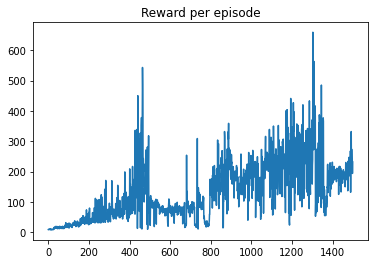

Episod reward: 166.0


In [28]:
if __name__=='__main__':
    env=gym.make("CartPole-v1", render_mode="rgb_array")
    model=Model(env)
    reward_per_episod=[]
    
    watch_agent(model,env,eps=0)
    
    n_episode =1500
    for it in range (n_episode):
        s=env.reset()[0]
        episode_reward=0
        done=False
        
        while not done:
            a= epsilon_greedy(model,s)
            s2,r,done,info,i=env.step(a)
            
            if done:
                target=r 
            else:
                values=model.predict_all_actions(s2)
                target= r+GAMMA * np.max(values)
                
            g=model.grad(s,a)
            err=target-model.predict(s,a)
            model.w +=ALPHA *err *g
        
            episode_reward +=r
        
            s=s2
        
        if (it+1) %50 ==0:
            print(f"Episode: {it+1}, Reward:{episode_reward}")
            
        if it >20 and np.mean(reward_per_episod[-20:])==200:
            print("Early exit")
            break
        
        reward_per_episod.append(episode_reward)
        
    test_reward= test_agent(model,env)
    print(f"Average test reward: {test_reward}")
    
    plt.plot(reward_per_episod)
    plt.title("Reward per episode")
    plt.show()
    
    watch_agent(model,env,eps=0)
        
        
        
                
            
    